<a href="https://colab.research.google.com/github/jplordelo92-rgb/AULA-COMPUTATIONAL-INTELLIGENCE-/blob/jplordelo92-rgb-patch-1/Fuzzy_Comida_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Serviço: 9.2 | Comida: 6.5 => Gorjeta Calculada: 16.06%


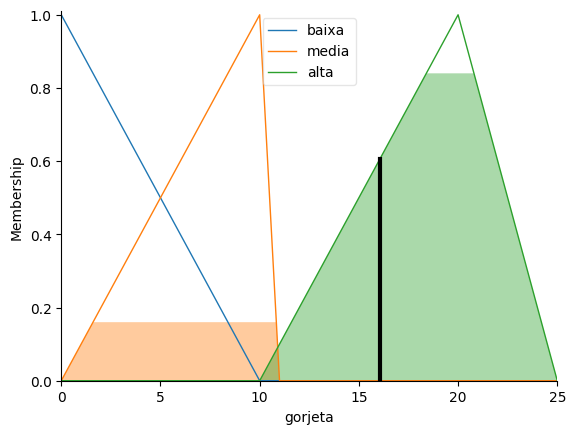

In [3]:
!pip install scikit-fuzzy

import numpy as np
import matplotlib.pyplot as plt
from skfuzzy import control as ctrl
import skfuzzy as fuzz

# --- CORREÇÃO DO BUG DO SCIKIT-FUZZY ---
# Inserimos os atributos que faltam para evitar o erro interno da biblioteca
ctrl.Antecedent.accumulation_method = np.fmax
ctrl.Antecedent.defuzzify_method = 'centroid'
# ---------------------------------------

#definir as variaveis da entrada da fuzzy
servico = ctrl.Antecedent(np.arange(0,11,1), 'servico')
comida = ctrl.Antecedent(np.arange(0,11,1), 'comida')

#consequente do fuzzy
gorjeta = ctrl.Consequent(np.arange(0,26,1), 'gorjeta')

#definir as funcoes de partinencia
servico['ruim'] = fuzz.trimf(servico.universe, [0,0,5])
servico['bom'] = fuzz.trimf(servico.universe, [0,5,10])
servico['excelente'] = fuzz.trimf(servico.universe, [5,10,10])
comida['ruim'] = fuzz.trimf(comida.universe, [0,0,5])
comida['boa'] = fuzz.trimf(comida.universe, [0,5,10])
comida['otima'] = fuzz.trimf(comida.universe, [5,10,10])

gorjeta['baixa'] = fuzz.trimf(gorjeta.universe, [0,0,10])
gorjeta['media'] = fuzz.trimf(gorjeta.universe, [0,10,10])
gorjeta['alta'] = fuzz.trimf(gorjeta.universe, [10,20,25])

#definir as regras do fuzzy usando operadores logicos corretos (Pode-se usar | para OR e & para AND)
regra1 = ctrl.Rule(servico['ruim'] | comida['ruim'], gorjeta['baixa'])
regra2 = ctrl.Rule(servico['bom'] & comida['boa'], gorjeta['media'])
regra3 = ctrl.Rule(servico['excelente'] | comida['otima'], gorjeta['alta'])

# --------------------------------------------------------------------------
# ETAPA 4: SISTEMA DE CONTROLE E SIMULAÇÃO
# --------------------------------------------------------------------------
# Criando controlador agrupando as regras definidas
controle_gorjeta = ctrl.ControlSystem([regra1, regra2, regra3])
simulacao = ctrl.ControlSystemSimulation(controle_gorjeta)

# Vamos simular um exemplo prático:
# Nota do Serviço: 9.2 (Excelente)
# Nota da Comida: 6.5 (Saborosa)
simulacao.input['servico'] = 9.2
simulacao.input['comida'] = 6.5

# Processando os cálculos matemáticos fuzzy (Fuzzificação -> Regras -> Defuzzificação)
simulacao.compute()

# Obtendo e exibindo o resultado numérico final
resultado_gorjeta = simulacao.output['gorjeta']
print(f"Serviço: 9.2 | Comida: 6.5 => Gorjeta Calculada: {resultado_gorjeta:.2f}%")

# --------------------------------------------------------------------------
# ETAPA 5: VISUALIZAÇÃO GRÁFICA
# --------------------------------------------------------------------------
# Mostrando a área resultante na curva de pertinência da gorjeta
gorjeta.view(sim=simulacao)
plt.show()